# L=32 raw-spin PCA — matched all-bin wide-grid analysis

## Matched data and analysis design

Every saved configuration is one observation. All ten bins for all 10,000 seeds and all 41 temperatures are included independently: **4.1 million observations per representation**. PCA and K-means are fitted on the same balanced 410,000 observation subset, then evaluated on every configuration. No spin inversion, temperature label, supervised classifier, or configuration averaging is used.

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import adjusted_mutual_info_score, silhouette_score

L = 32
N_SITES = L ** 2
N_RUNS = 10_000
N_TEMPERATURES = 41
BINS_PER_TEMPERATURE = 10
N_CONFIGURATIONS = N_RUNS * N_TEMPERATURES * BINS_PER_TEMPERATURE
TEMPERATURES = np.array([2.133034, 2.155726, 2.178418, 2.201110, 2.223802, 2.235148, 2.240820, 2.246493, 2.252166, 2.257839, 2.263512, 2.269185, 2.274858, 2.280531, 2.286204, 2.291877, 2.297550, 2.303223, 2.308896, 2.314569, 2.320242, 2.325915, 2.331588, 2.337261, 2.342934, 2.348607, 2.354280, 2.359953, 2.365626, 2.371299, 2.376972, 2.382645, 2.388318, 2.393991, 2.416682, 2.439374, 2.462066, 2.484758, 2.507450, 2.530142, 2.541488], dtype=np.float64)
TC = 2.0 / np.log(1.0 + np.sqrt(2.0))

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parents[1]]
REPO_ROOT = next(root for root in candidate_roots if (root / "data" / "raw" / "ising32_wide_dense").exists())
DATA_ROOT = REPO_ROOT / "data" / "raw" / "ising32_wide_dense"
OUTPUT_ROOT = REPO_ROOT / "data" / "processed" / "ising32_wide_dense" / "matched_all_bins"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

run_dirs = sorted(DATA_ROOT.glob("ising32_wide_dense_[0-9]*"), key=lambda p: int(p.name.rsplit("_", 1)[1]))
assert len(run_dirs) == N_RUNS

SPINS_PATH = OUTPUT_ROOT / "all_spin_configurations.npy"
if not SPINS_PATH.exists():
    cache = np.lib.format.open_memmap(
        SPINS_PATH, mode="w+", dtype=np.int8,
        shape=(N_CONFIGURATIONS, L, L),
    )
    offset = 0
    for run_index, run_dir in enumerate(run_dirs):
        name = run_dir.name
        block = np.loadtxt(run_dir / f"spinConfigs_{name}.txt", dtype=np.int8).reshape(-1, L, L)
        assert block.shape == (N_TEMPERATURES * BINS_PER_TEMPERATURE, L, L)
        cache[offset:offset + len(block)] = block
        offset += len(block)
        if (run_index + 1) % 500 == 0:
            print(f"Cached {run_index + 1:,}/{N_RUNS:,} runs")
    cache.flush()
    del cache

all_spins = np.load(SPINS_PATH, mmap_mode="r")
assert all_spins.shape == (N_CONFIGURATIONS, L, L)
configuration_temperatures = np.tile(np.repeat(TEMPERATURES, BINS_PER_TEMPERATURE), N_RUNS)

# The same balanced 410,000 configurations fit both PCA bases and both K-means models:
# one rotating bin for every seed-temperature pair. All 4.1 million configurations are
# subsequently transformed, assigned, and included in temperature-population curves.
run_ids = np.arange(N_RUNS)[:, None]
temperature_ids = np.arange(N_TEMPERATURES)[None, :]
fit_bins = (run_ids + temperature_ids) % BINS_PER_TEMPERATURE
FIT_INDICES = ((run_ids * N_TEMPERATURES + temperature_ids) * BINS_PER_TEMPERATURE + fit_bins).reshape(-1)
assert len(FIT_INDICES) == N_RUNS * N_TEMPERATURES

signed_magnetization = all_spins.reshape(N_CONFIGURATIONS, -1).mean(axis=1, dtype=np.float64).astype(np.float32)
print(f"{N_CONFIGURATIONS:,} matched configurations; {len(FIT_INDICES):,} balanced fit observations")
print(f"Temperature range: {TEMPERATURES[0]:.3f}–{TEMPERATURES[-1]:.3f}; device={torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

4,100,000 matched configurations; 410,000 balanced fit observations
Temperature range: 2.133–2.541; device=cuda


## Magnetization calculated directly from the spins

For each saved configuration, calculate the signed magnetization per site directly as

\[
m = \frac{1}{L^2}\sum_{i=1}^{L^2}s_i.
\]

The plotted order parameter is the temperature-wise mean absolute magnetization, \(\langle |m|\rangle\). Error bars are the standard error over all 100,000 configurations at each temperature (10,000 seeds × 10 saved bins).

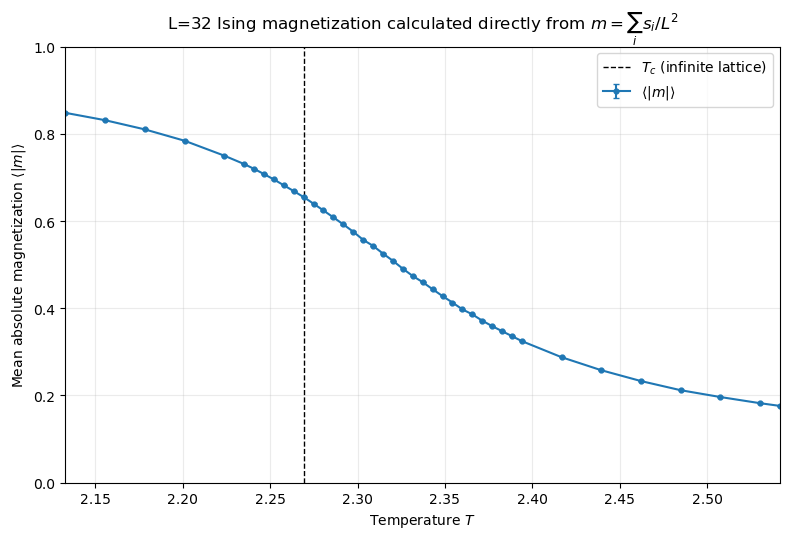

,temperature,mean_absolute_magnetization,standard_error,n_configurations
0,2.133034,0.847973,0.000175,100000
1,2.155726,0.831108,0.000208,100000
2,2.178418,0.810032,0.000250,100000
3,2.201110,0.784054,0.000307,100000
4,2.223802,0.749868,0.000386,100000
5,2.235148,0.730655,0.000422,100000
6,2.240820,0.719614,0.000442,100000
7,2.246493,0.707734,0.000468,100000
8,2.252166,0.695298,0.000490,100000
9,2.257839,0.681966,0.000515,100000


In [2]:
# signed_magnetization was calculated directly from all_spins by summing over L^2 sites.
magnetization_rows = []
for temperature in TEMPERATURES:
    values = np.abs(signed_magnetization[configuration_temperatures == temperature])
    magnetization_rows.append({
        "temperature": temperature,
        "mean_absolute_magnetization": float(values.mean()),
        "standard_error": float(values.std(ddof=1) / np.sqrt(len(values))),
        "n_configurations": int(len(values)),
    })

magnetization_table = pd.DataFrame(magnetization_rows)
magnetization_table.to_csv(
    OUTPUT_ROOT / "ising32_all_bins_absolute_magnetization.csv", index=False
)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.errorbar(
    magnetization_table.temperature,
    magnetization_table.mean_absolute_magnetization,
    yerr=magnetization_table.standard_error,
    fmt="o-",
    markersize=3.5,
    linewidth=1.5,
    capsize=2,
    label=r"$\langle |m| \rangle$",
)
ax.axvline(
    TC,
    color="black",
    linestyle="--",
    linewidth=1,
    label=r"$T_c$ (infinite lattice)",
)
ax.set(
    xlabel="Temperature $T$",
    ylabel=r"Mean absolute magnetization $\langle |m| \rangle$",
    title=r"L=32 Ising magnetization calculated directly from $m=\sum_i s_i/L^2$",
    xlim=(TEMPERATURES.min(), TEMPERATURES.max()),
    ylim=(0, 1),
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(
    OUTPUT_ROOT / "ising32_all_bins_absolute_magnetization.png",
    dpi=250,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)
magnetization_table

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def fit_covariance_pca(features, cache_path, batch_size=4096):
    if cache_path.exists():
        saved = np.load(cache_path)
        return saved["mean"], saved["eigenvalues"], saved["components"]
    dimension = features.shape[1]
    total = torch.zeros(dimension, dtype=torch.float64, device=DEVICE)
    second = torch.zeros((dimension, dimension), dtype=torch.float64, device=DEVICE)
    for start in range(0, len(FIT_INDICES), batch_size):
        indices = FIT_INDICES[start:start + batch_size]
        batch = torch.tensor(np.asarray(features[indices], dtype=np.float32), device=DEVICE, dtype=torch.float64)
        total += batch.sum(0)
        second += batch.T @ batch
    mean_t = total / len(FIT_INDICES)
    covariance = (second - len(FIT_INDICES) * torch.outer(mean_t, mean_t)) / (len(FIT_INDICES) - 1)
    values, vectors = torch.linalg.eigh(covariance)
    order = torch.argsort(values, descending=True)
    mean = mean_t.cpu().numpy()
    eigenvalues = values[order].cpu().numpy()
    components = vectors[:, order].T.cpu().numpy()
    np.savez(cache_path, mean=mean, eigenvalues=eigenvalues, components=components)
    return mean, eigenvalues, components

def project(features, indices, mean, components):
    return (np.asarray(features[indices], dtype=np.float32) - mean) @ components.T

def score_first_six(features, mean, components, cache_path, batch_size=8192):
    if cache_path.exists():
        return np.load(cache_path, mmap_mode="r")
    cache = np.lib.format.open_memmap(cache_path, mode="w+", dtype=np.float32, shape=(N_CONFIGURATIONS, 6))
    for start in range(0, N_CONFIGURATIONS, batch_size):
        stop = min(start + batch_size, N_CONFIGURATIONS)
        cache[start:stop] = (np.asarray(features[start:stop], dtype=np.float32) - mean) @ components[:6].T
    cache.flush(); del cache
    return np.load(cache_path, mmap_mode="r")

def overview_plot(scores6, representation_name, file_name):
    rng = np.random.default_rng(2026)
    sample = np.concatenate([
        rng.choice(np.flatnonzero(configuration_temperatures == t), size=2000, replace=False)
        for t in TEMPERATURES
    ])
    means = np.empty((N_TEMPERATURES, 6))
    errors = np.empty_like(means)
    for ti, t in enumerate(TEMPERATURES):
        values = np.asarray(scores6[configuration_temperatures == t])
        means[ti] = values.mean(0)
        errors[ti] = values.std(0, ddof=1) / np.sqrt(len(values))

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))
    scatter = axes[0].scatter(
        scores6[sample, 0], scores6[sample, 1], c=configuration_temperatures[sample],
        s=2, alpha=.3, cmap="turbo", rasterized=True,
    )
    axes[0].set(xlabel="PC1 score", ylabel="PC2 score", title=f"{representation_name}: first two PCs")
    fig.colorbar(scatter, ax=axes[0], label="Temperature $T$")
    for pc in range(6):
        axes[1].errorbar(TEMPERATURES, means[:, pc], yerr=errors[:, pc], marker="o", ms=2.5, lw=1, label=f"PC{pc+1}")
    axes[1].axvline(TC, color="black", ls="--", lw=1, label="$T_c$ (infinite lattice)")
    axes[1].set(xlabel="Temperature $T$", ylabel="Mean PC score", title="First six PC coordinates vs. temperature")
    axes[1].grid(alpha=.25); axes[1].legend(ncol=2, fontsize=8)
    fig.suptitle("All ten saved configurations are included independently")
    fig.tight_layout(); fig.savefig(OUTPUT_ROOT / file_name, dpi=250, bbox_inches="tight")
    plt.show(); plt.close(fig)

def variance_plot(eigenvalues, representation_name, file_name):
    evr = eigenvalues / eigenvalues.sum()
    cumulative = np.cumsum(evr)
    n90 = int(np.searchsorted(cumulative, .9) + 1)
    shown = min(max(n90, 10), 80)
    x = np.arange(1, shown + 1)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x, evr[:shown], color="tab:blue", alpha=.8, label="Individual variance")
    ax.set(xlabel="Principal component", ylabel="Explained variance ratio", title=f"{representation_name}: {n90} PCs retain 90% variance")
    ax.grid(axis="y", alpha=.25)
    other = ax.twinx(); other.plot(x, cumulative[:shown], color="tab:red", marker="o", ms=2, label="Cumulative variance")
    other.axhline(.9, color="black", ls="--", lw=1); other.set(ylabel="Cumulative explained variance", ylim=(0, 1.02))
    handles, labels = ax.get_legend_handles_labels(); h2, l2 = other.get_legend_handles_labels(); ax.legend(handles+h2, labels+l2)
    fig.tight_layout(); fig.savefig(OUTPUT_ROOT / file_name, dpi=250, bbox_inches="tight"); plt.show(); plt.close(fig)
    return evr, cumulative, n90

def tail_plots(scores6, prefix, representation_name):
    tail_count = max(1, int(.02 * N_CONFIGURATIONS))
    extrema_rows = []
    fig, axes = plt.subplots(5, 2, figsize=(8, 17), constrained_layout=True)
    tail_fig, tail_axes = plt.subplots(5, 3, figsize=(10, 17), constrained_layout=True)
    for pc in range(5):
        values = np.asarray(scores6[:, pc])
        low = np.argpartition(values, tail_count)[:tail_count]
        high = np.argpartition(values, len(values) - tail_count)[-tail_count:]
        minimum, maximum = int(np.argmin(values)), int(np.argmax(values))
        for col, (direction, index) in enumerate((("Most negative score", minimum), ("Most positive score", maximum))):
            axes[pc, col].imshow(all_spins[index], cmap="gray", vmin=-1, vmax=1, interpolation="nearest")
            axes[pc, col].set_title(f"PC{pc+1}: {direction}\nT={configuration_temperatures[index]:.3f}, m={signed_magnetization[index]:+.3f}, score={values[index]:+.2f}")
            axes[pc, col].set_xticks([]); axes[pc, col].set_yticks([])
            extrema_rows.append({"pc": pc+1, "direction": direction, "index": index, "temperature": configuration_temperatures[index], "magnetization": signed_magnetization[index], "score": values[index]})
        low_map = np.asarray(all_spins[low], dtype=np.float32).mean(0)
        high_map = np.asarray(all_spins[high], dtype=np.float32).mean(0)
        maps = (low_map, high_map, high_map-low_map)
        limit = max(float(np.max(np.abs(maps))), 1e-3)
        titles = ("Bottom 2%: mean spin", "Top 2%: mean spin", "Top minus bottom")
        for col, (image, title) in enumerate(zip(maps, titles)):
            tail_axes[pc, col].imshow(image, cmap="RdBu_r", vmin=-limit, vmax=limit, interpolation="nearest")
            tail_axes[pc, col].set_title(title if pc == 0 else "")
            tail_axes[pc, col].set_xticks([]); tail_axes[pc, col].set_yticks([])
        tail_axes[pc, 0].set_ylabel(f"PC{pc+1} score tails", fontsize=12)
    fig.suptitle(f"{representation_name}: actual configurations at PC1–PC5 score extrema", fontsize=15)
    fig.savefig(OUTPUT_ROOT / f"{prefix}_pc1-5_extreme_configurations.png", dpi=250, bbox_inches="tight"); plt.show(); plt.close(fig)
    tail_fig.suptitle(f"{representation_name}: average spin pattern in the bottom and top 2% of each PC score\nRed = mostly +1, blue = mostly −1", fontsize=14)
    tail_fig.savefig(OUTPUT_ROOT / f"{prefix}_pc1-5_tail_average_spin_patterns.png", dpi=250, bbox_inches="tight"); plt.show(); plt.close(tail_fig)
    pd.DataFrame(extrema_rows).to_csv(OUTPUT_ROOT / f"{prefix}_pc1-5_extrema.csv", index=False)

def streamed_kmeans(features, mean, components, n90, prefix, representation_name, batch_size=8192):
    fit_full = np.asarray(features[FIT_INDICES], dtype=np.float32)
    fit_pca = (fit_full - mean) @ components[:n90].T
    models = {
        "PCA 90%": MiniBatchKMeans(3, random_state=42, batch_size=8192, n_init=20, max_iter=300).fit(fit_pca),
        f"Full {features.shape[1]}-D": MiniBatchKMeans(3, random_state=42, batch_size=8192, n_init=20, max_iter=300).fit(fit_full),
    }
    all_labels = {}
    summaries = []
    population_frames = []
    diagnostics = []
    rng = np.random.default_rng(42)
    diagnostic_indices = np.concatenate([rng.choice(np.flatnonzero(configuration_temperatures == t), 125, replace=False) for t in TEMPERATURES])
    for method, model in models.items():
        labels = np.lib.format.open_memmap(OUTPUT_ROOT / f"{prefix}_{method.split()[0].lower()}_cluster_labels.npy", mode="w+", dtype=np.int8, shape=(N_CONFIGURATIONS,))
        for start in range(0, N_CONFIGURATIONS, batch_size):
            stop = min(start + batch_size, N_CONFIGURATIONS)
            block = np.asarray(features[start:stop], dtype=np.float32)
            if method == "PCA 90%": block = (block - mean) @ components[:n90].T
            labels[start:stop] = model.predict(block)
        labels.flush()
        unordered = np.asarray(labels)
        cluster_mean_m = np.array([signed_magnetization[unordered == k].mean() for k in range(3)])
        cluster_mean_abs = np.array([np.abs(signed_magnetization[unordered == k]).mean() for k in range(3)])
        disordered = int(np.argmin(cluster_mean_abs))
        ordered = [k for k in range(3) if k != disordered]
        negative, positive = sorted(ordered, key=lambda k: cluster_mean_m[k])
        mapping = np.empty(3, dtype=np.int8); mapping[negative]=0; mapping[disordered]=1; mapping[positive]=2
        labels[:] = mapping[unordered]; labels.flush()
        aligned = np.asarray(labels)
        all_labels[method] = aligned.copy()
        for cluster, name in enumerate(("Negative ordered", "Low-|m| / disordered", "Positive ordered")):
            mask = aligned == cluster
            summaries.append({"method": method, "cluster": cluster, "physical_label": name, "fraction": mask.mean(), "mean_m": signed_magnetization[mask].mean(), "mean_abs_m": np.abs(signed_magnetization[mask]).mean()})
        rows=[]
        for t in TEMPERATURES:
            at_t = aligned[configuration_temperatures == t]
            for cluster in range(3): rows.append({"method": method, "temperature": t, "cluster": cluster, "fraction": np.mean(at_t == cluster)})
        population_frames.append(pd.DataFrame(rows))
        diag_block = np.asarray(features[diagnostic_indices], dtype=np.float32)
        if method == "PCA 90%": diag_block = (diag_block - mean) @ components[:n90].T
        diagnostics.append({"method": method, "silhouette": silhouette_score(diag_block, aligned[diagnostic_indices]), "sample_size": len(diagnostic_indices)})
    populations = pd.concat(population_frames, ignore_index=True)
    names = ("Negative ordered ($m<0$)", "Low-$|m|$ / disordered", "Positive ordered ($m>0$)")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
    for ax, method in zip(axes, models):
        for cluster, name in enumerate(names):
            data = populations[(populations.method == method) & (populations.cluster == cluster)]
            ax.plot(data.temperature, data.fraction, "o-", ms=3, label=name)
        ax.axvline(TC, color="black", ls="--", lw=1); ax.set(xlabel="Temperature $T$", title=method, xlim=(TEMPERATURES.min(), TEMPERATURES.max()), ylim=(-.02,1.02)); ax.grid(alpha=.25); ax.legend(fontsize=8)
    axes[0].set_ylabel("Fraction of configurations assigned")
    fig.suptitle(f"{representation_name}: unsupervised cluster populations (all ten bins)")
    fig.tight_layout(); fig.savefig(OUTPUT_ROOT / f"{prefix}_cluster_populations.png", dpi=250, bbox_inches="tight"); plt.show(); plt.close(fig)
    summary = pd.DataFrame(summaries); diagnostics = pd.DataFrame(diagnostics)
    diagnostics["PCA_vs_full_AMI"] = adjusted_mutual_info_score(all_labels["PCA 90%"], all_labels[f"Full {features.shape[1]}-D"])
    summary.to_csv(OUTPUT_ROOT / f"{prefix}_cluster_summary.csv", index=False); populations.to_csv(OUTPUT_ROOT / f"{prefix}_cluster_populations.csv", index=False); diagnostics.to_csv(OUTPUT_ROOT / f"{prefix}_cluster_diagnostics.csv", index=False)
    return all_labels, summary, diagnostics

## Build the representation

In [4]:
raw_features = all_spins.reshape(N_CONFIGURATIONS, N_SITES)
print("Raw feature matrix:", raw_features.shape, raw_features.dtype)

Raw feature matrix: (4100000, 1024) int8


## PCA structure, PC tails, and unsupervised clustering

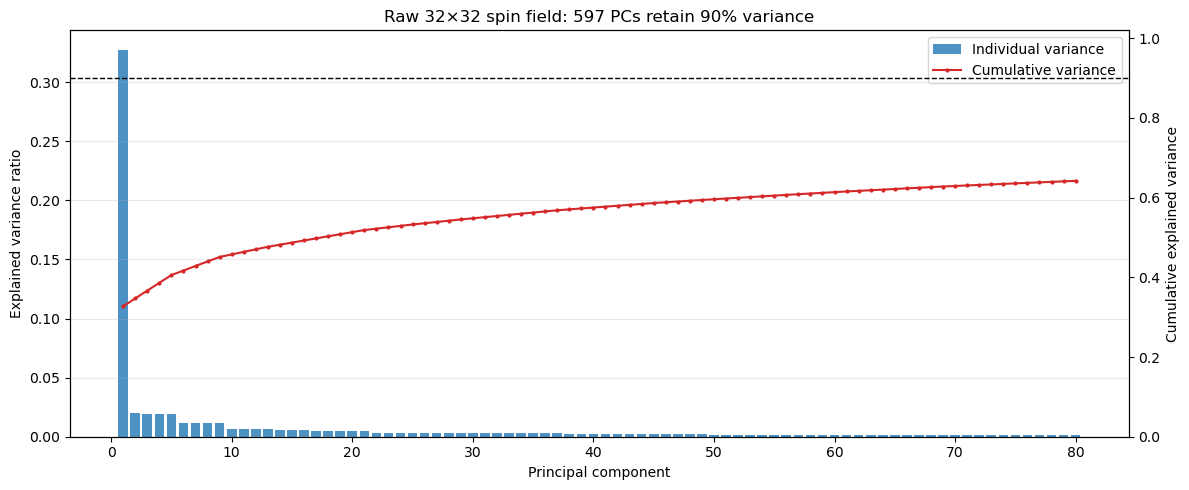

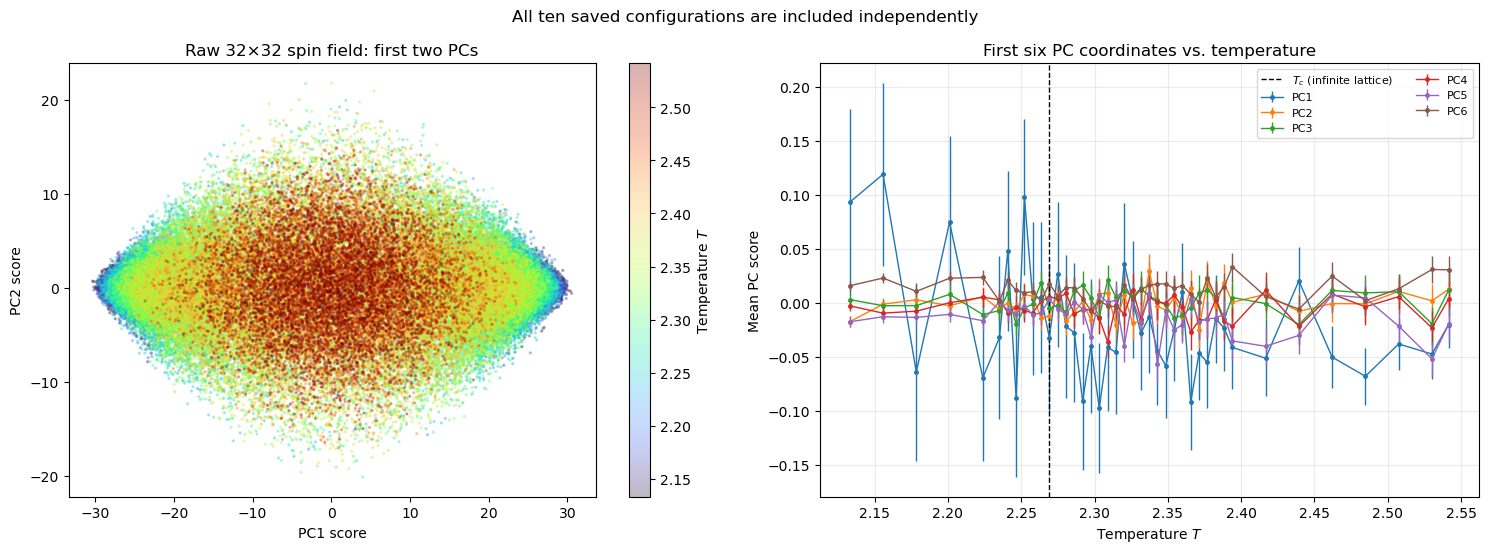

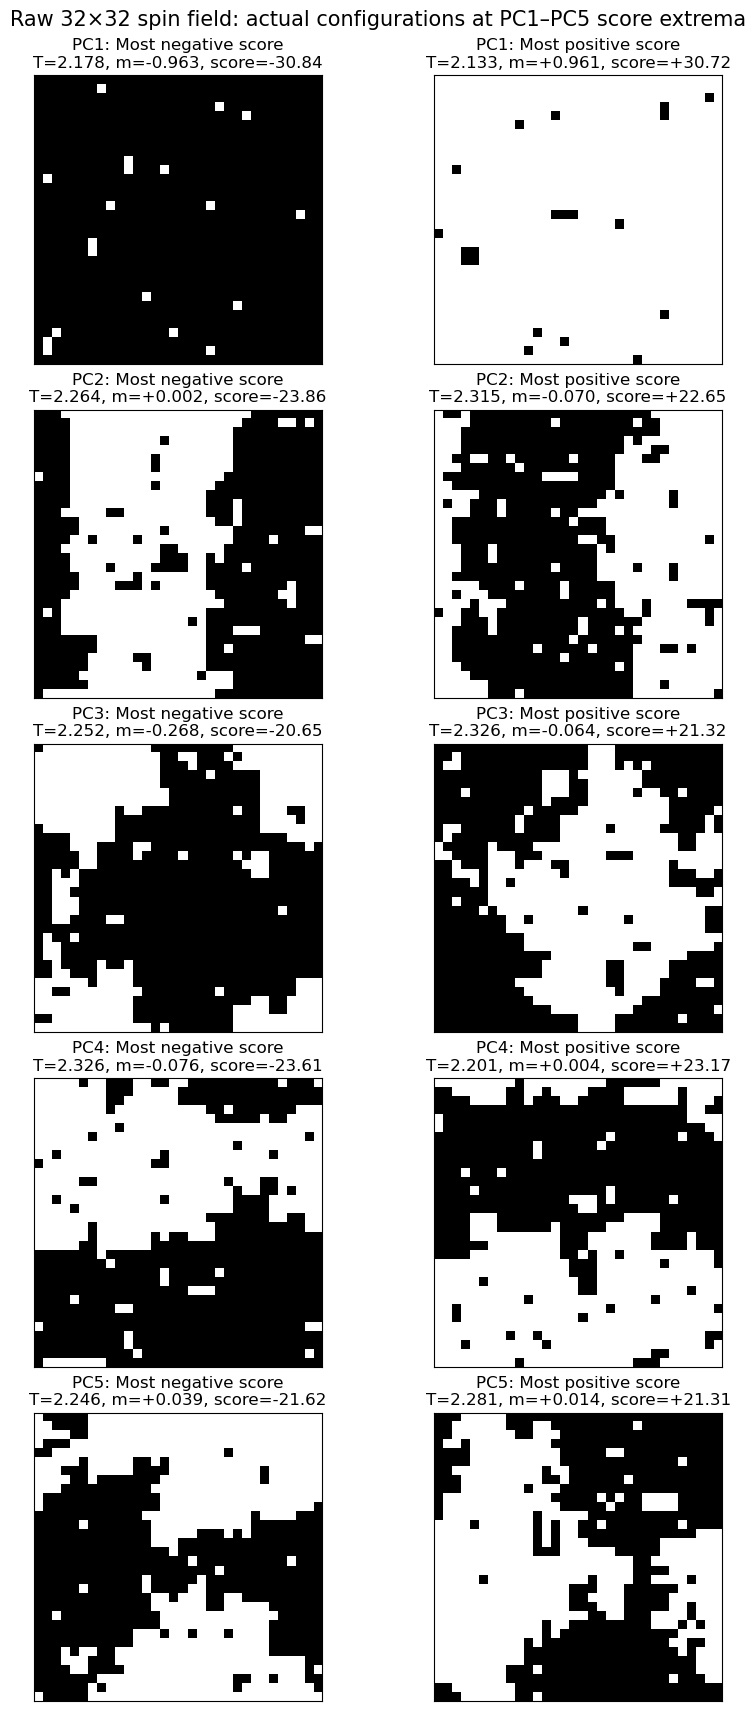

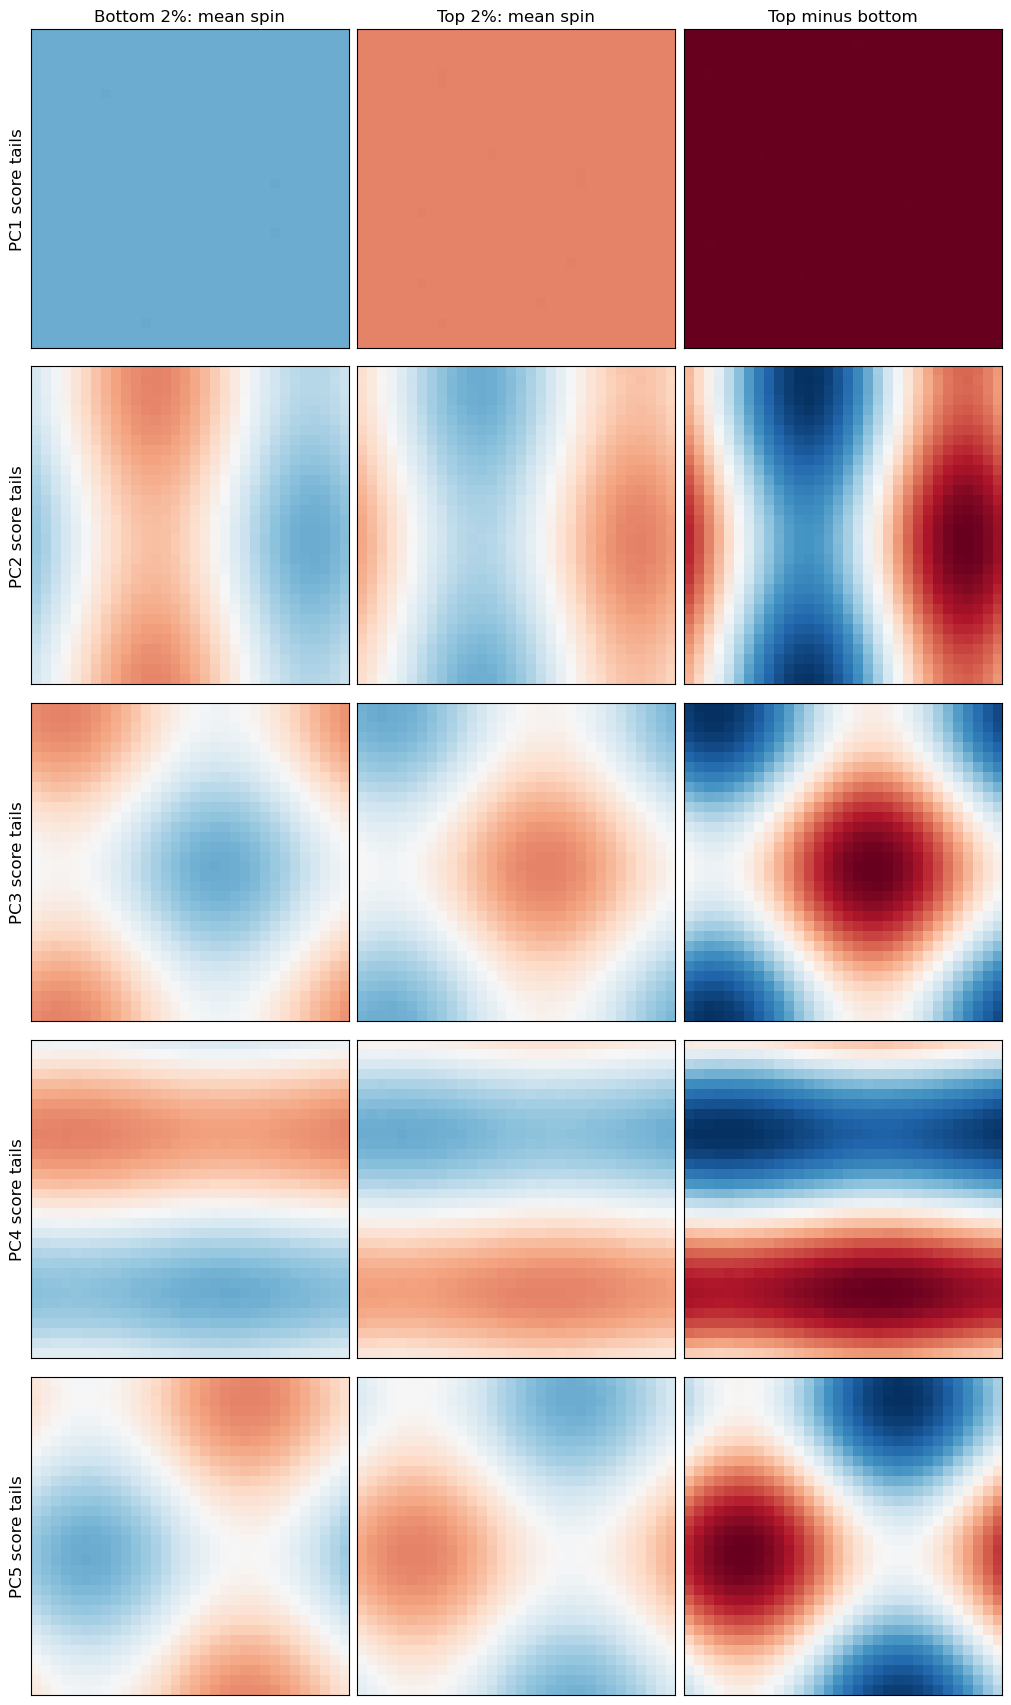

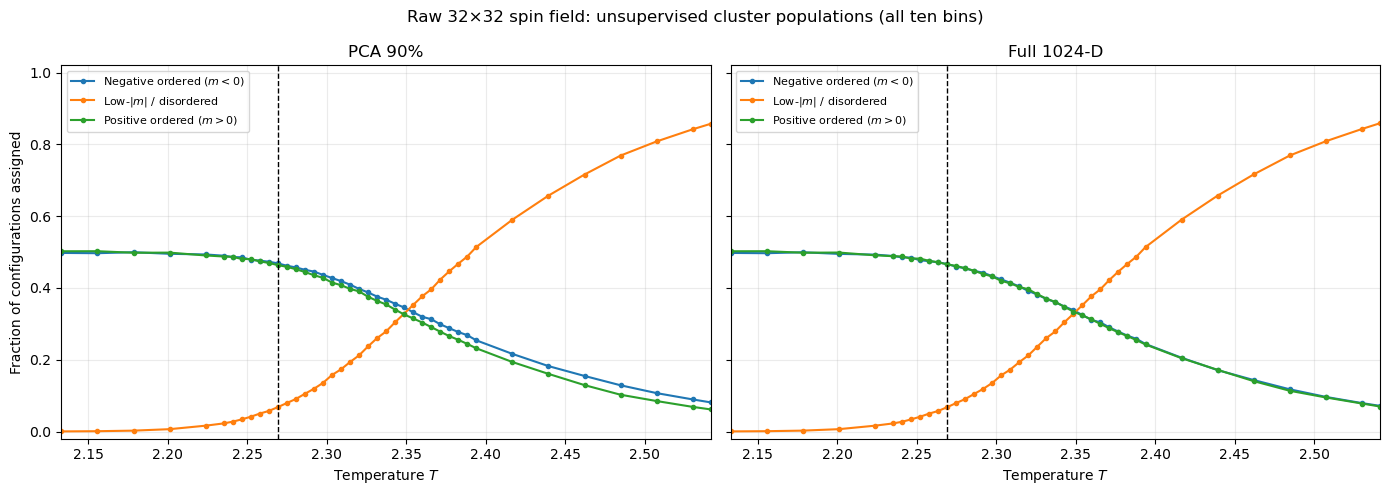

,method,cluster,physical_label,fraction,mean_m,mean_abs_m
0,PCA 90%,0,Negative ordered,0.363086,-0.642084,0.642084
1,PCA 90%,1,Low-|m| / disordered,0.285484,0.013402,0.158908
2,PCA 90%,2,Positive ordered,0.351430,0.653309,0.653309
3,Full 1024-D,0,Negative ordered,0.357532,-0.647168,0.647168
4,Full 1024-D,1,Low-|m| / disordered,0.285380,0.000742,0.158552
5,Full 1024-D,2,Positive ordered,0.357088,0.648184,0.648184


,method,silhouette,sample_size,PCA_vs_full_AMI
0,PCA 90%,0.176657,5125,0.948344
1,Full 1024-D,0.160080,5125,0.948344


In [5]:
raw_features = all_spins.reshape(N_CONFIGURATIONS, N_SITES)
mean, eigenvalues, components = fit_covariance_pca(raw_features, OUTPUT_ROOT / "raw_spin_all_bins_pca.npz")
evr, cumulative, n90 = variance_plot(eigenvalues, "Raw 32×32 spin field", "raw_spin_all_bins_explained_variance.png")
scores6 = score_first_six(raw_features, mean, components, OUTPUT_ROOT / "raw_spin_all_bins_pc1-6_scores.npy")
overview_plot(scores6, "Raw 32×32 spin field", "raw_spin_all_bins_pca_overview.png")
tail_plots(scores6, "raw_spin_all_bins", "Raw 32×32 spin field")
labels, cluster_summary, diagnostics = streamed_kmeans(raw_features, mean, components, n90, "raw_spin_all_bins", "Raw 32×32 spin field")
with open(OUTPUT_ROOT / "raw_spin_all_bins_summary.json", "w") as handle:
    json.dump({"observations": N_CONFIGURATIONS, "fit_observations": len(FIT_INDICES), "n90": n90, "first_six_evr": evr[:6].tolist()}, handle, indent=2)
display(cluster_summary, diagnostics)

## Direct apples-to-apples comparison

In [6]:
resnet_summary = json.loads((OUTPUT_ROOT / "resnet18_all_bins_summary.json").read_text())
resnet_diag = pd.read_csv(OUTPUT_ROOT / "resnet18_all_bins_cluster_diagnostics.csv")
raw_diag = pd.read_csv(OUTPUT_ROOT / "raw_spin_all_bins_cluster_diagnostics.csv")
comparison = pd.DataFrame({
    "representation": ["Frozen ResNet-18", "Raw spins"],
    "PCs for 90% variance": [resnet_summary["n90"], n90],
    "PCA90 silhouette": [resnet_diag.loc[resnet_diag.method == "PCA 90%", "silhouette"].iloc[0], raw_diag.loc[raw_diag.method == "PCA 90%", "silhouette"].iloc[0]],
    "Full-space silhouette": [resnet_diag.loc[resnet_diag.method.str.startswith("Full"), "silhouette"].iloc[0], raw_diag.loc[raw_diag.method.str.startswith("Full"), "silhouette"].iloc[0]],
})
resnet_pca_labels = np.load(OUTPUT_ROOT / "resnet18_all_bins_pca_cluster_labels.npy", mmap_mode="r")
raw_pca_labels = np.load(OUTPUT_ROOT / "raw_spin_all_bins_pca_cluster_labels.npy", mmap_mode="r")
comparison["Cross-representation PCA90 AMI"] = adjusted_mutual_info_score(resnet_pca_labels, raw_pca_labels)
comparison.to_csv(OUTPUT_ROOT / "matched_resnet_vs_raw_comparison.csv", index=False)
comparison

,representation,PCs for 90% variance,PCA90 silhouette,Full-space silhouette,Cross-representation PCA90 AMI
0,Frozen ResNet-18,32,0.287853,0.249135,0.692316
1,Raw spins,597,0.176657,0.160080,0.692316


## Dimension-matched clustering: raw PCs 1–32

ResNet reaches 90% explained variance with 32 PCs. To separate representation quality from dimensionality and from the inappropriate 90%-variance rule for raw spins, fit a third raw-spin K-means model using exactly the first **32 raw PCs**. This uses the same balanced fitting observations, all 4.1 million configurations for population curves, three clusters, initialization count, and physical label alignment as the ResNet analysis.

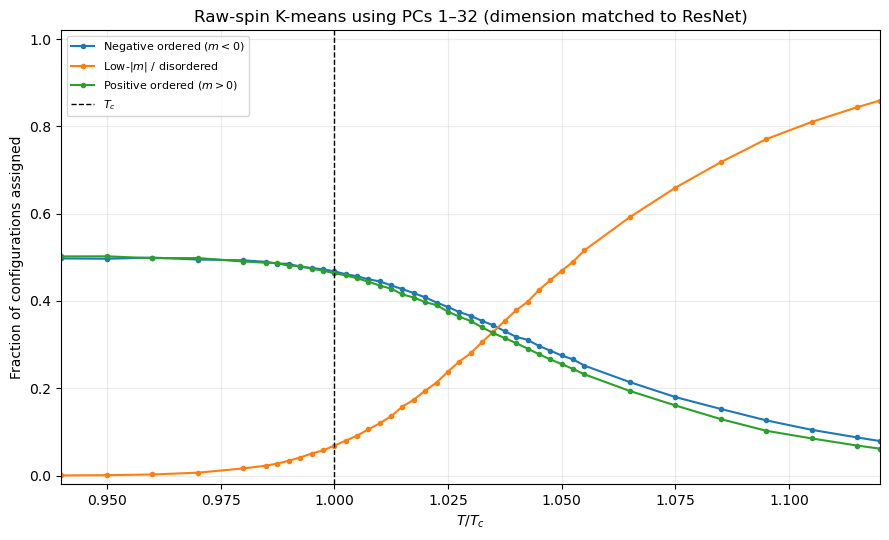

,n_components,raw_variance_retained,silhouette,AMI_vs_raw_PCA90,AMI_vs_ResNet_32PC
0,32,0.554006,0.290577,0.989654,0.693313


,cluster,physical_label,fraction,mean_signed_m,mean_abs_m
0,0,Negative ordered (m<0),0.361957,-0.643121,0.643121
1,1,Low-|m| / disordered,0.286582,0.012095,0.159484
2,2,Positive ordered (m>0),0.351461,0.653280,0.653280


In [7]:
N_MATCHED_PCS = 32
raw_first32_variance = float(np.sum(evr[:N_MATCHED_PCS]))

fit_raw = np.asarray(raw_features[FIT_INDICES], dtype=np.float32)
fit_first32 = (fit_raw - mean) @ components[:N_MATCHED_PCS].T
raw32_model = MiniBatchKMeans(
    n_clusters=3,
    random_state=42,
    batch_size=8192,
    n_init=20,
    max_iter=300,
).fit(fit_first32)

raw32_label_path = OUTPUT_ROOT / "raw_spin_first32_cluster_labels.npy"
raw32_labels = np.lib.format.open_memmap(
    raw32_label_path, mode="w+", dtype=np.int8, shape=(N_CONFIGURATIONS,)
)
batch_size = 8192
for start in range(0, N_CONFIGURATIONS, batch_size):
    stop = min(start + batch_size, N_CONFIGURATIONS)
    block = np.asarray(raw_features[start:stop], dtype=np.float32)
    scores = (block - mean) @ components[:N_MATCHED_PCS].T
    raw32_labels[start:stop] = raw32_model.predict(scores)
raw32_labels.flush()

# Reorder clusters as negative ordered, low-|m|/disordered, positive ordered.
unordered = np.asarray(raw32_labels)
mean_m = np.array([signed_magnetization[unordered == k].mean() for k in range(3)])
mean_abs_m = np.array([np.abs(signed_magnetization[unordered == k]).mean() for k in range(3)])
disordered = int(np.argmin(mean_abs_m))
ordered = [k for k in range(3) if k != disordered]
negative, positive = sorted(ordered, key=lambda k: mean_m[k])
mapping = np.empty(3, dtype=np.int8)
mapping[negative], mapping[disordered], mapping[positive] = 0, 1, 2
raw32_labels[:] = mapping[unordered]
raw32_labels.flush()
raw32_labels_array = np.asarray(raw32_labels)

cluster_names = (
    "Negative ordered ($m<0$)",
    "Low-$|m|$ / disordered",
    "Positive ordered ($m>0$)",
)
population_rows = []
for temperature in TEMPERATURES:
    labels_at_temperature = raw32_labels_array[configuration_temperatures == temperature]
    for cluster in range(3):
        population_rows.append({
            "temperature": temperature,
            "temperature_over_tc": temperature / TC,
            "cluster": cluster,
            "physical_label": cluster_names[cluster],
            "fraction": float(np.mean(labels_at_temperature == cluster)),
        })
raw32_populations = pd.DataFrame(population_rows)
raw32_populations.to_csv(
    OUTPUT_ROOT / "raw_spin_first32_cluster_populations.csv", index=False
)

fig, ax = plt.subplots(figsize=(9, 5.5))
for cluster, label in enumerate(cluster_names):
    data = raw32_populations[raw32_populations.cluster == cluster]
    ax.plot(data.temperature / TC, data.fraction, "o-", markersize=3, label=label)
ax.axvline(1.0, color="black", linestyle="--", linewidth=1, label="$T_c$")
ax.set(
    xlabel="$T/T_c$",
    ylabel="Fraction of configurations assigned",
    title="Raw-spin K-means using PCs 1–32 (dimension matched to ResNet)",
    xlim=(TEMPERATURES.min() / TC, TEMPERATURES.max() / TC),
    ylim=(-0.02, 1.02),
)
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(
    OUTPUT_ROOT / "raw_spin_first32_cluster_populations.png",
    dpi=250,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

rng = np.random.default_rng(42)
diagnostic_indices = np.concatenate([
    rng.choice(np.flatnonzero(configuration_temperatures == t), 125, replace=False)
    for t in TEMPERATURES
])
diagnostic_features = (
    np.asarray(raw_features[diagnostic_indices], dtype=np.float32) - mean
) @ components[:N_MATCHED_PCS].T
raw32_silhouette = silhouette_score(
    diagnostic_features, raw32_labels_array[diagnostic_indices]
)

raw32_summary = pd.DataFrame({
    "cluster": range(3),
    "physical_label": [name.replace("$", "") for name in cluster_names],
    "fraction": [np.mean(raw32_labels_array == k) for k in range(3)],
    "mean_signed_m": [signed_magnetization[raw32_labels_array == k].mean() for k in range(3)],
    "mean_abs_m": [np.abs(signed_magnetization[raw32_labels_array == k]).mean() for k in range(3)],
})
raw32_summary.to_csv(OUTPUT_ROOT / "raw_spin_first32_cluster_summary.csv", index=False)

raw_pca90_labels = np.load(
    OUTPUT_ROOT / "raw_spin_all_bins_pca_cluster_labels.npy", mmap_mode="r"
)
resnet32_labels = np.load(
    OUTPUT_ROOT / "resnet18_all_bins_pca_cluster_labels.npy", mmap_mode="r"
)
raw32_diagnostics = pd.DataFrame([{
    "n_components": N_MATCHED_PCS,
    "raw_variance_retained": raw_first32_variance,
    "silhouette": raw32_silhouette,
    "AMI_vs_raw_PCA90": adjusted_mutual_info_score(raw32_labels_array, raw_pca90_labels),
    "AMI_vs_ResNet_32PC": adjusted_mutual_info_score(raw32_labels_array, resnet32_labels),
}])
raw32_diagnostics.to_csv(
    OUTPUT_ROOT / "raw_spin_first32_cluster_diagnostics.csv", index=False
)
display(raw32_diagnostics, raw32_summary)

## Interpretation

Raw-spin PCA uses the exact same 4.1 million configurations and balanced fitting subset as ResNet. The 90%-variance rule retains **597 raw PCs**, compared with 32 for ResNet, but those hundreds of additional low-variance spatial directions are not helpful for Euclidean K-means.

The dimension-matched first-32-PC raw representation retains **55.4%** of raw-spin variance and obtains silhouette **0.291**. This is slightly higher than ResNet’s 32-PC silhouette of **0.288**, and far higher than raw PCA-90 (**0.177**) or full raw-spin space (**0.160**). Its assignments are almost identical to raw PCA-90 (AMI **0.990**) and retain comparable agreement with ResNet (AMI **0.693**). Thus, truncating raw PCA does not invent a different phase division; it removes distance-diluting microscopic directions.

At (T/T_c=0.94), the 32-PC low-|m| cluster contains only **0.039%** of configurations. At (T/T_c=1.12), it reaches **85.92%**. ResNet still produces a cleaner high-temperature endpoint at approximately **96.8%**, but it does **not** have better overall silhouette once dimensionality is controlled.

The scientifically appropriate conclusion is therefore nuanced: ResNet compresses 90% of its feature variance into 32 directions and produces a more saturated disordered endpoint, while carefully truncated raw PCA is equally or slightly more compact under the silhouette metric and remains more physically interpretable. The earlier conclusion that ResNet clearly outperformed raw PCA was mostly an artifact of using the 90%-variance cutoff independently for representations with very different variance spectra.